# Constraint Satisfaction Matcher

The ConstraintSatisfactionMatcher can be used to optimize any linear function of the baseline covariates. We support constraints on the size of the subset populations and the allowed mismatch.

Here, we demonstrate the optimization of balance subject to size constraints only. Namely, we solve:

\begin{equation}
\begin{aligned}
& \underset{\hat{P}}{\text{minimize}}
& & \sum_k |\mu_{\hat{P}k} - \mu_{Tk}| \\
& \text{subject to}
& & |\hat{P}| = P^* \\
& & & |\hat{T}| = T^* \\
\end{aligned}
\end{equation}

where $P$ and $T$ refer to two populations we are trying to match, $\hat{P}$ and $\hat{T}$ are the subsets of $P$ and $T$ we are seeking, $P^*$ and $T^*$ are fixed integers, and  $k$ indexes the covariates of $P$ and $T$.

In [1]:
import logging 
logging.basicConfig(
    format="%(levelname)-4s [%(filename)s:%(lineno)d] %(message)s",
    level='INFO',
)
from pybalance.utils import (
    BetaBalance, 
    BetaXBalance, 
    GammaBalance, 
    GammaXBalance,
    GammaXTreeBalance
)
from pybalance.sim import generate_toy_dataset
from pybalance.lp import ConstraintSatisfactionMatcher
from pybalance.visualization import (
    plot_numeric_features, 
    plot_categoric_features, 
    plot_binary_features,
    plot_per_feature_loss,
)

In [2]:
time_limit = 60

In [3]:
m = generate_toy_dataset()
m

,age,height,weight,gender,haircolor,country,population,binary_0,binary_1,binary_2,binary_3,patient_id
0,62.511573,190.229250,105.165097,0.0,2,3,pool,0,0,0,0,0
1,68.505065,161.121236,95.001474,0.0,1,1,pool,1,0,1,0,1
2,50.071384,162.325356,84.290576,1.0,0,5,pool,0,0,1,1,2
3,44.423692,150.948096,82.031381,1.0,2,2,pool,0,0,0,1,3
4,41.695052,132.952651,54.857540,0.0,1,3,pool,0,0,1,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...
995,21.474205,168.602546,70.342128,0.0,2,5,target,0,0,0,1,10995
996,40.643320,188.188724,61.611744,0.0,2,4,target,1,0,0,1,10996
997,29.472765,161.408162,57.214095,0.0,0,1,target,0,1,1,1,10997
998,41.291949,150.968833,91.270798,0.0,0,3,target,0,0,0,0,10998


## Optimize Beta (Mean Absolute SMD)

In [4]:
objective = beta = BetaBalance(m)
matcher = matcher_beta = ConstraintSatisfactionMatcher(
    m, 
    time_limit=time_limit,
    objective=objective,
    ps_hinting=False,
    num_workers=4)
matcher.get_params()

INFO [matcher.py:66] Scaling features by factor 240.00 in order to use integer solver with <= 0.2841% loss.


{'objective': 'beta',
 'pool_size': 1000,
 'target_size': 1000,
 'max_mismatch': None,
 'time_limit': 60,
 'num_workers': 4,
 'ps_hinting': False,
 'verbose': True}

In [5]:
matcher.match()

INFO [matcher.py:499] Solving for match population with pool size = 1000 and target size = 1000, optimizing balance (no max_mismatch cap).
INFO [matcher.py:503] Matching on 15 dimensions ...
INFO [matcher.py:510] Building model variables and constraints ...
INFO [matcher.py:519] Calculating bounds on feature variables ...
INFO [matcher.py:609] Applying size constraints on pool and target ...
INFO [matcher.py:239] Solving with 4 workers ...
INFO [matcher.py:91] Initial balance score: 0.2328
INFO [matcher.py:97] =========================================
INFO [matcher.py:98] Solution 1, time = 0.02 m
INFO [matcher.py:102] Objective:	452948000.0
INFO [matcher.py:123] Balance (beta):	0.2298
INFO [matcher.py:128] Patients (pool):	1000
INFO [matcher.py:130] Patients (target):	1000
INFO [matcher.py:146]  
INFO [matcher.py:97] =========================================
INFO [matcher.py:98] Solution 2, time = 0.03 m
INFO [matcher.py:102] Objective:	452876000.0
INFO [matcher.py:123] Balance (beta)

,age,height,weight,gender,haircolor,country,population,binary_0,binary_1,binary_2,binary_3,patient_id
0,55.261578,139.396134,94.438359,0.0,2,2,target,0,0,1,1,10000
1,63.113091,165.563337,67.433016,1.0,2,2,target,0,1,1,0,10001
2,58.232216,160.859857,71.915385,1.0,0,2,target,0,0,0,0,10002
3,58.996941,140.357415,115.606615,1.0,0,3,target,1,1,0,0,10003
4,36.850195,189.983706,53.000581,0.0,2,5,target,0,0,0,0,10004
...,...,...,...,...,...,...,...,...,...,...,...,...
9933,68.194783,127.495418,69.177329,0.0,1,5,pool,1,1,0,0,9933
9958,51.722321,170.350117,80.695438,0.0,2,4,pool,0,1,0,1,9958
9966,40.121009,168.339212,100.428001,1.0,2,4,pool,0,1,1,0,9966
9981,39.006118,133.419182,71.135407,0.0,1,4,pool,0,0,0,0,9981


Note that it is possible for the "balance" value to go up (hopefully only slightly) as the solver progresses. This behavior is due to rounding errors incurred when casting a continuous problem into the discrete space understood by the solver. The "balance" reported here is the actual balance computed to full accuracy on the original dataset; the "objective" value here is the actual quantity being optimized and should never increase.

In [6]:
matcher.get_best_match()

,age,height,weight,gender,haircolor,country,population,binary_0,binary_1,binary_2,binary_3,patient_id
0,55.261578,139.396134,94.438359,0.0,2,2,target,0,0,1,1,10000
1,63.113091,165.563337,67.433016,1.0,2,2,target,0,1,1,0,10001
2,58.232216,160.859857,71.915385,1.0,0,2,target,0,0,0,0,10002
3,58.996941,140.357415,115.606615,1.0,0,3,target,1,1,0,0,10003
4,36.850195,189.983706,53.000581,0.0,2,5,target,0,0,0,0,10004
...,...,...,...,...,...,...,...,...,...,...,...,...
9933,68.194783,127.495418,69.177329,0.0,1,5,pool,1,1,0,0,9933
9958,51.722321,170.350117,80.695438,0.0,2,4,pool,0,1,0,1,9958
9966,40.121009,168.339212,100.428001,1.0,2,4,pool,0,1,1,0,9966
9981,39.006118,133.419182,71.135407,0.0,1,4,pool,0,0,0,0,9981


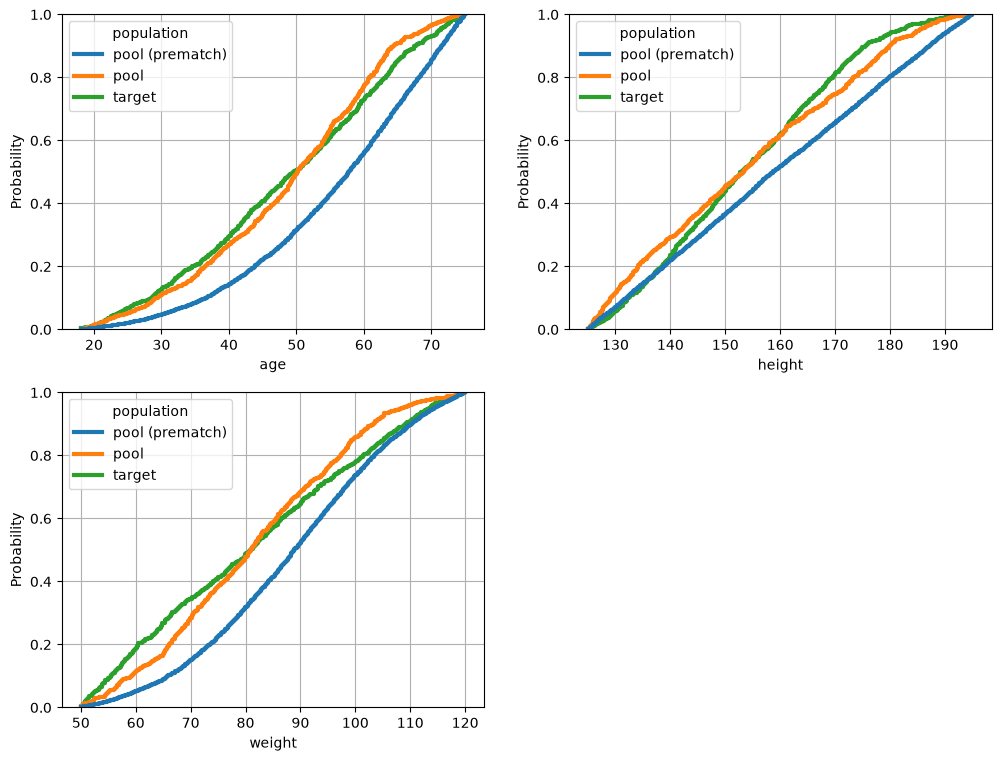

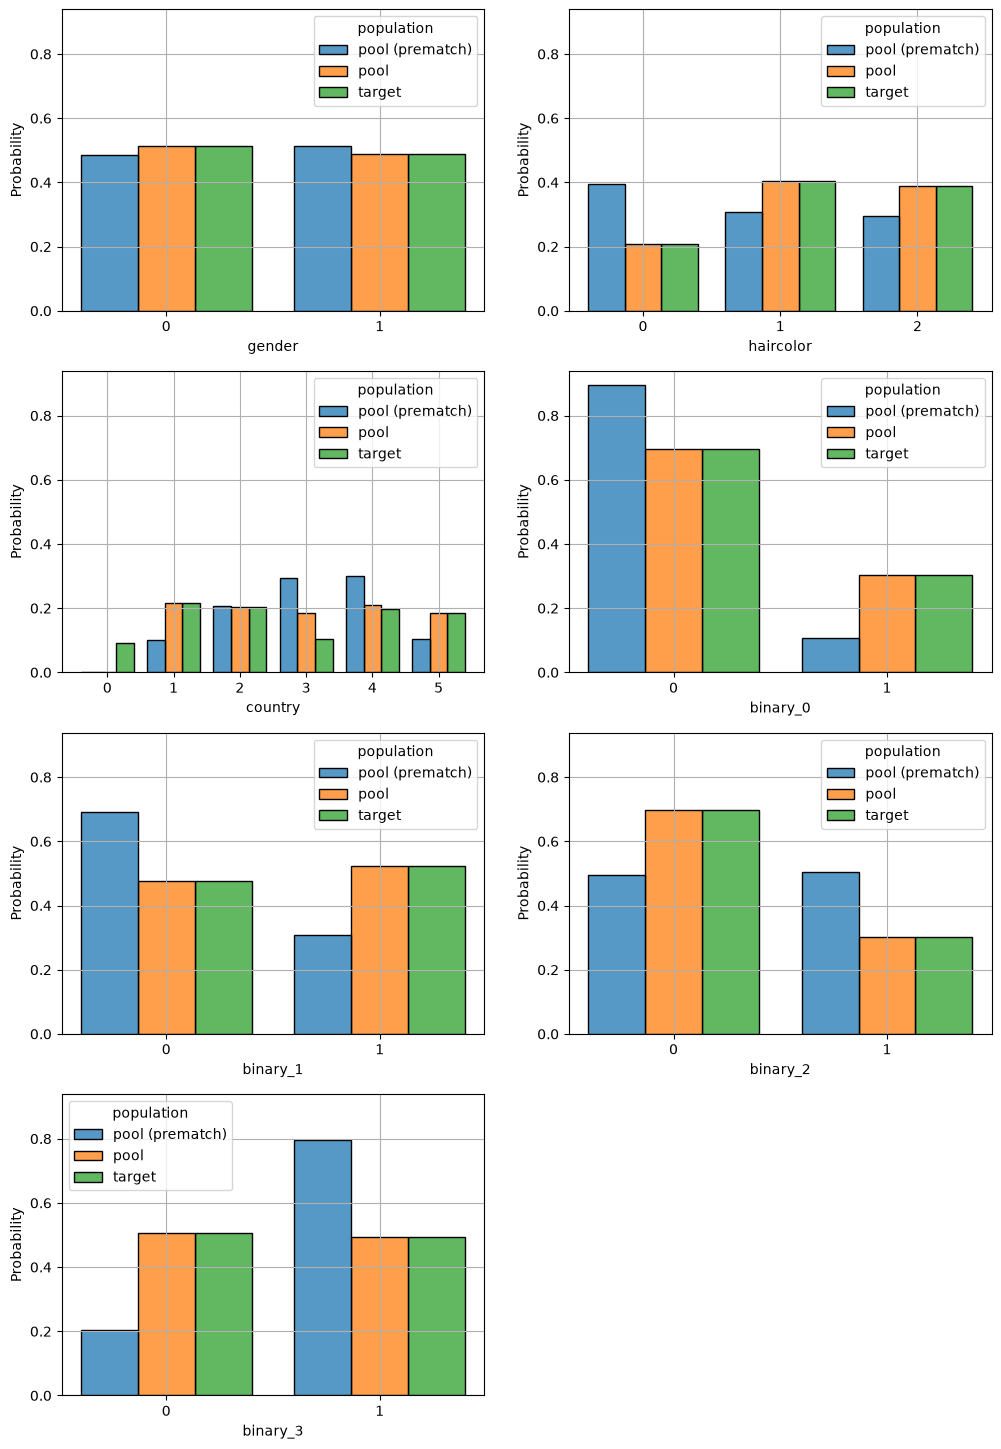

In [7]:
%matplotlib inline

match = matcher.get_best_match()
m_data = m.copy().get_population('pool')
m_data.loc[:, 'population'] = m_data['population'] + ' (prematch)'
match.append(m_data)
# fig = plot_per_feature_loss(match, beta, 'target', debin=False)
fig = plot_numeric_features(match, hue_order=['pool (prematch)', 'pool', 'target', ])
fig = plot_categoric_features(match,  hue_order=['pool (prematch)', 'pool', 'target'])


## Optimize Beta With Cross Terms Added

Sometimes it helps to add a known (non-optimal) solution as a hint to the solver. A natural choice for hinting the solver is to take a solution from PS matching. We can choose to use the PS as a hint to the solver by passing ps_hinting=True.

In [8]:
objective = beta_x = BetaXBalance(m)
matcher = matcher_betax = ConstraintSatisfactionMatcher(
    m, 
    time_limit=time_limit,
    objective=objective,
    ps_hinting=True,
    num_workers=4)
matcher.get_params()

INFO [preprocess.py:548] Added cross term height * weight to matching features.
INFO [preprocess.py:548] Added cross term gender * age to matching features.
INFO [preprocess.py:548] Added cross term binary_0 * binary_3 to matching features.
INFO [preprocess.py:548] Added cross term binary_0 * age to matching features.
INFO [preprocess.py:548] Added cross term binary_3 * weight to matching features.
INFO [preprocess.py:548] Added cross term binary_2 * weight to matching features.
INFO [preprocess.py:548] Added cross term binary_1 * binary_3 to matching features.
INFO [preprocess.py:548] Added cross term binary_2 * binary_3 to matching features.
INFO [preprocess.py:548] Added cross term binary_2 * height to matching features.
INFO [preprocess.py:548] Added cross term binary_0 * binary_2 to matching features.
INFO [matcher.py:66] Scaling features by factor 240.00 in order to use integer solver with <= 0.3751% loss.


{'objective': 'beta_x',
 'pool_size': 1000,
 'target_size': 1000,
 'max_mismatch': None,
 'time_limit': 60,
 'num_workers': 4,
 'ps_hinting': True,
 'verbose': True}

In [9]:
matcher.match()

INFO [matcher.py:499] Solving for match population with pool size = 1000 and target size = 1000, optimizing balance (no max_mismatch cap).
INFO [matcher.py:503] Matching on 25 dimensions ...
INFO [matcher.py:510] Building model variables and constraints ...
INFO [matcher.py:519] Calculating bounds on feature variables ...
INFO [matcher.py:609] Applying size constraints on pool and target ...
INFO [matcher.py:615] Applying hint ...
INFO [matcher.py:622] Training PS model as guide for solver ...
INFO [preprocess.py:548] Added cross term height * weight to matching features.
INFO [preprocess.py:548] Added cross term gender * age to matching features.
INFO [preprocess.py:548] Added cross term binary_0 * binary_3 to matching features.
INFO [preprocess.py:548] Added cross term binary_0 * age to matching features.
INFO [preprocess.py:548] Added cross term binary_3 * weight to matching features.
INFO [preprocess.py:548] Added cross term binary_2 * weight to matching features.
INFO [preprocess.

,age,height,weight,gender,haircolor,country,population,binary_0,binary_1,binary_2,binary_3,patient_id
0,55.261578,139.396134,94.438359,0.0,2,2,target,0,0,1,1,10000
1,63.113091,165.563337,67.433016,1.0,2,2,target,0,1,1,0,10001
2,58.232216,160.859857,71.915385,1.0,0,2,target,0,0,0,0,10002
3,58.996941,140.357415,115.606615,1.0,0,3,target,1,1,0,0,10003
4,36.850195,189.983706,53.000581,0.0,2,5,target,0,0,0,0,10004
...,...,...,...,...,...,...,...,...,...,...,...,...
9933,68.194783,127.495418,69.177329,0.0,1,5,pool,1,1,0,0,9933
9947,64.290077,168.091011,63.511962,1.0,2,2,pool,0,0,0,1,9947
9975,51.242281,130.812647,87.967028,1.0,0,4,pool,1,0,1,0,9975
9983,68.616093,167.546870,58.683367,1.0,0,2,pool,0,0,0,0,9983


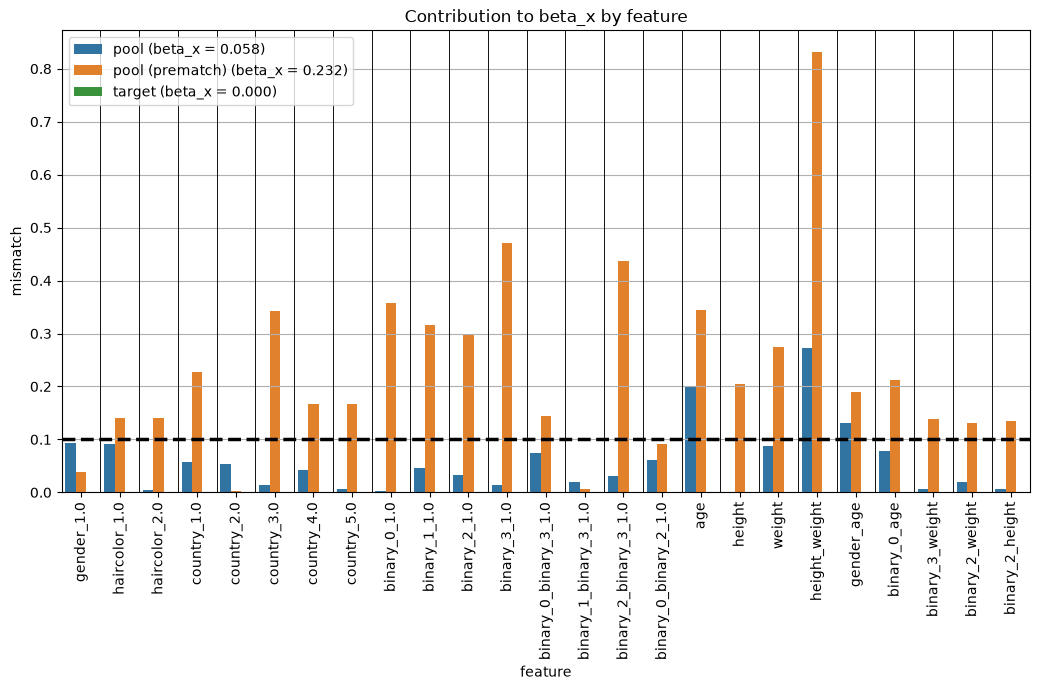

In [10]:
%matplotlib inline

match = matcher.get_best_match()
m_data = m.copy().get_population('pool')
m_data.loc[:, 'population'] = m_data['population'] + ' (prematch)'
match.append(m_data)
fig = plot_per_feature_loss(match, objective, 'target', debin=False)

## Optimize Gamma (Area Between CDFs)

In [11]:
objective = gamma = GammaBalance(m)
matcher = matcher_gamma = ConstraintSatisfactionMatcher(
    m, 
    time_limit=time_limit,
    objective=objective,
    ps_hinting=True,
    num_workers=4)
matcher.get_params()

INFO [preprocess.py:340] Discretized age with bins [18.05, 27.54, 37.04, 46.53, 56.02, 65.51, 75.0].
INFO [preprocess.py:340] Discretized height with bins [125.01, 136.68, 148.34, 160.01, 171.67, 183.34, 195.0].
INFO [preprocess.py:340] Discretized weight with bins [50.0, 61.67, 73.33, 85.0, 96.66, 108.33, 120.0].
INFO [matcher.py:66] Scaling features by factor 200.00 in order to use integer solver with <= 0.0000% loss.


{'objective': 'gamma',
 'pool_size': 1000,
 'target_size': 1000,
 'max_mismatch': None,
 'time_limit': 60,
 'num_workers': 4,
 'ps_hinting': True,
 'verbose': True}

In [12]:
matcher.match()

INFO [matcher.py:499] Solving for match population with pool size = 1000 and target size = 1000, optimizing balance (no max_mismatch cap).
INFO [matcher.py:503] Matching on 27 dimensions ...
INFO [matcher.py:510] Building model variables and constraints ...
INFO [matcher.py:519] Calculating bounds on feature variables ...
INFO [matcher.py:609] Applying size constraints on pool and target ...
INFO [matcher.py:615] Applying hint ...
INFO [matcher.py:622] Training PS model as guide for solver ...
INFO [preprocess.py:340] Discretized age with bins [18.05, 27.54, 37.04, 46.53, 56.02, 65.51, 75.0].
INFO [preprocess.py:340] Discretized height with bins [125.01, 136.68, 148.34, 160.01, 171.67, 183.34, 195.0].
INFO [preprocess.py:340] Discretized weight with bins [50.0, 61.67, 73.33, 85.0, 96.66, 108.33, 120.0].
INFO [matcher.py:179] Training model SGDClassifier (iter 1/50, 0.001 min) ...
INFO [matcher.py:139] Best propensity score match found:
INFO [matcher.py:140] 	Model: SGDClassifier
INFO [

,age,height,weight,gender,haircolor,country,population,binary_0,binary_1,binary_2,binary_3,patient_id
0,55.261578,139.396134,94.438359,0.0,2,2,target,0,0,1,1,10000
1,63.113091,165.563337,67.433016,1.0,2,2,target,0,1,1,0,10001
2,58.232216,160.859857,71.915385,1.0,0,2,target,0,0,0,0,10002
3,58.996941,140.357415,115.606615,1.0,0,3,target,1,1,0,0,10003
4,36.850195,189.983706,53.000581,0.0,2,5,target,0,0,0,0,10004
...,...,...,...,...,...,...,...,...,...,...,...,...
9932,72.514956,159.248205,118.505187,0.0,1,5,pool,1,1,0,1,9932
9933,68.194783,127.495418,69.177329,0.0,1,5,pool,1,1,0,0,9933
9957,63.949429,170.485188,99.498013,1.0,2,5,pool,0,0,1,0,9957
9981,39.006118,133.419182,71.135407,0.0,1,4,pool,0,0,0,0,9981


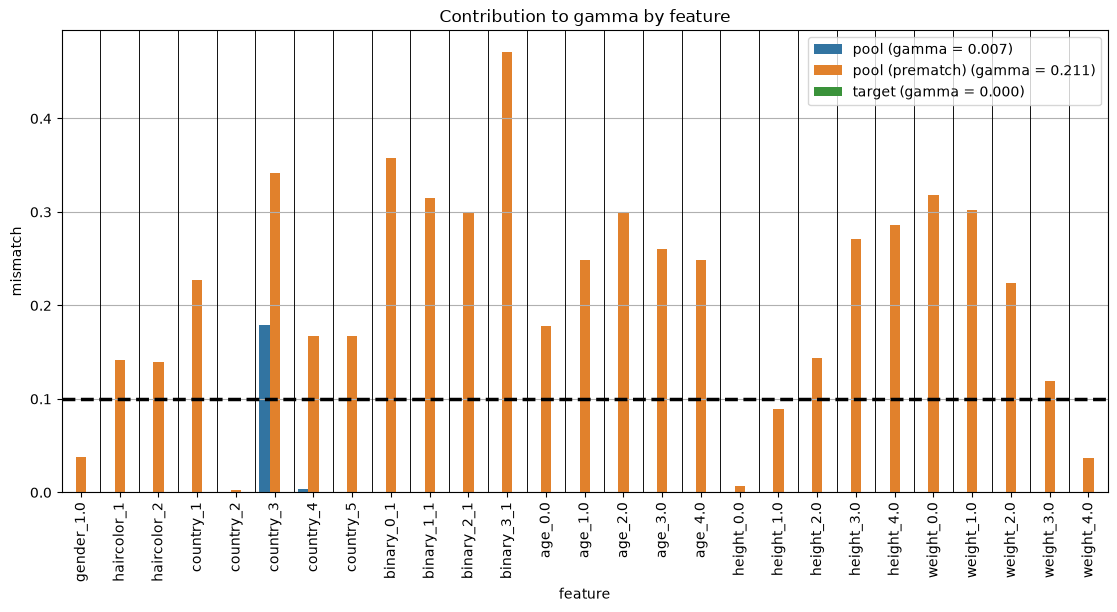

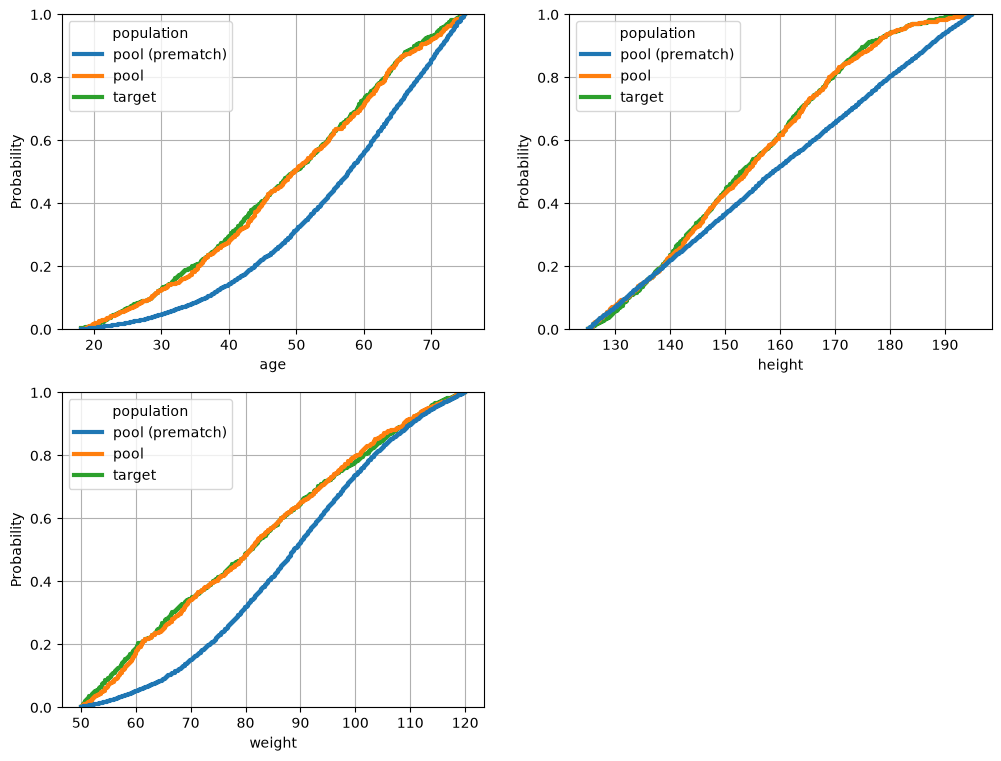

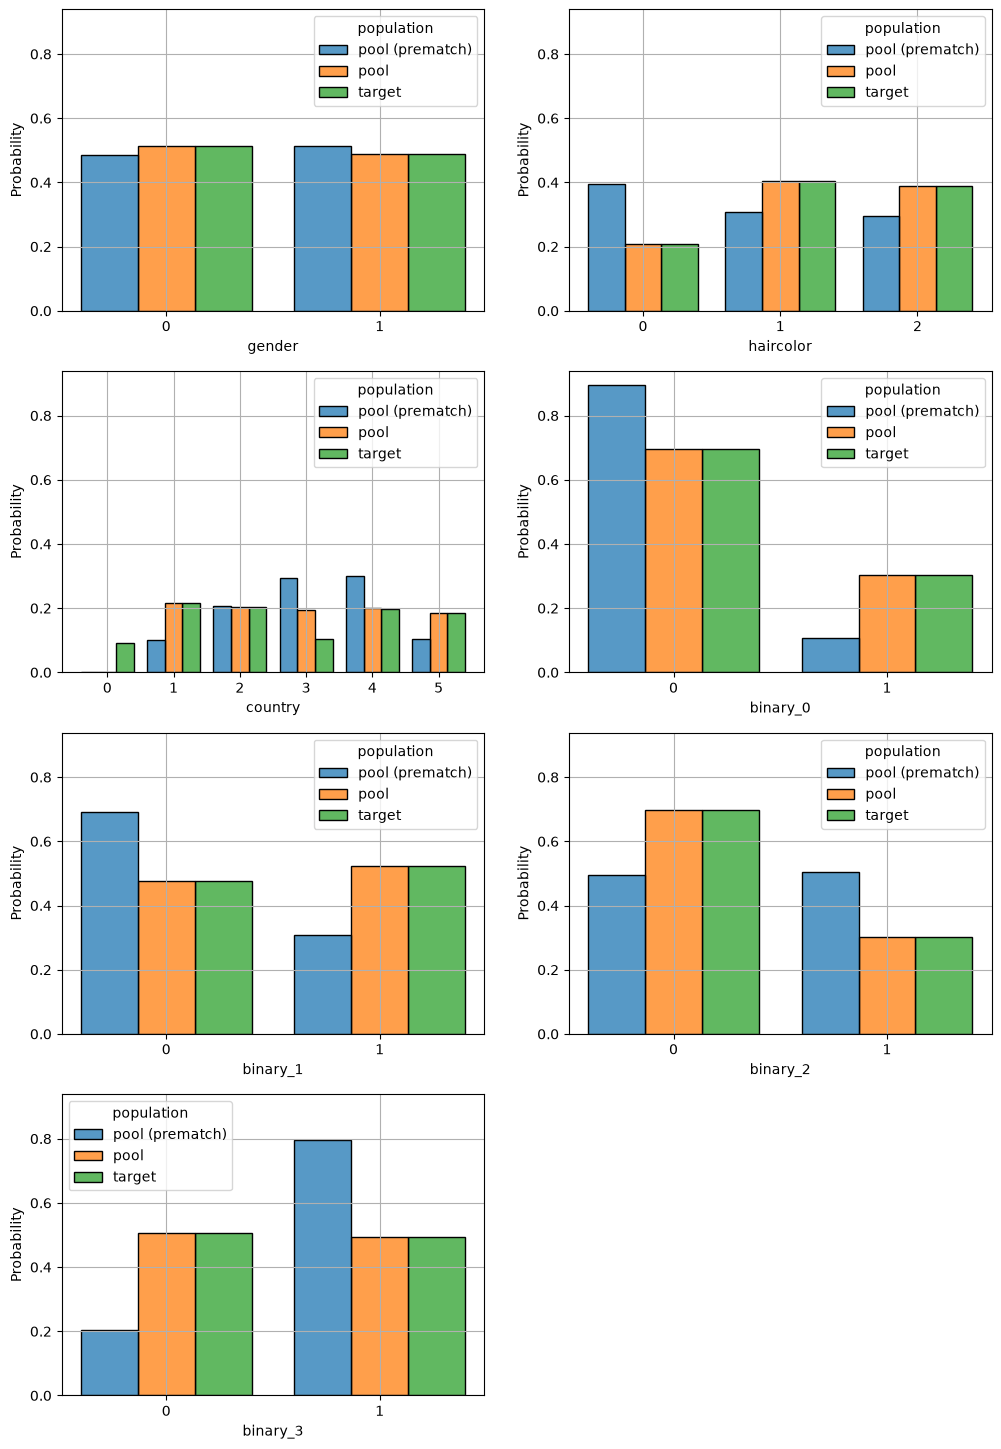

In [13]:
%matplotlib inline

match = matcher.get_best_match()
m_data = m.copy().get_population('pool')
m_data.loc[:, 'population'] = m_data['population'] + ' (prematch)'
match.append(m_data)
fig = plot_per_feature_loss(match, objective, 'target', debin=False)
fig = plot_numeric_features(match, hue_order=['pool (prematch)', 'pool', 'target', ])
fig = plot_categoric_features(match,  hue_order=['pool (prematch)', 'pool', 'target'])